In [85]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

graphviz_path = r"c:\\Program Files\\Graphviz\bin"

# 将路径添加到系统的 PATH 环境变量中
os.environ["PATH"] += os.pathsep + graphviz_path

In [99]:
# the value unit
from typing import List


class Value:
    # `label`用来表示流图上的节点名字
    # `grad` 代表参与计算的公式中作用于最终结果的梯度(全局梯度)
    def __init__(self, data, children=(), _op="", label=""):
        # print(children, set(children))
        self.data = data
        self._prev = set["Value"](
            children
        )  # 这里是把元组转换成了集合, 并非新建一个集合存储单个元组
        self._op = _op
        self.label = label
        self.grad = 0.0
        # ===> backward impls
        self._backward = lambda: None

    # print format
    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    # 重载操作符, 在对应运算时时将值的来源的记录下来
    def __add__(self, rhs: "Value | float"):
        # support primitive numbers
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)

        out = Value(self.data + rhs.data, (self, rhs), "+")

        # ===> backward impls
        # mul case: chain rule o = self + rhs  self.grad = do/dself = do/drhs = 1.0 ,vice versa
        def _backward():
            # refactor into accumulting the gradient
            self.grad += 1.0 * out.grad
            rhs.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, lhs: "Value| float"):
        return self.__add__(lhs)

    def __mul__(self, rhs: "Value| float"):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)

        out = Value(self.data * rhs.data, (self, rhs), "*")

        # ===> backward impls
        # mul case: chain rule o = self * rhs  self.grad = do/dself = rhs ,vice versa
        def _backward():
            # refactor into accumulting the gradient
            self.grad += rhs.data * out.grad
            rhs.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, lhs: "Value| float"):
        return self.__mul__(lhs)  # 直接复用 __mul__

    # from `implement tanh` tanh 激活函数: (e^2x - 1)/(e^2x + 1)
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), _op="tanh")

        # ===> backward impls
        # tanh case:  # do/dn = 1 - tanh(x) ^2  => 1-o^2
        def _backward():
            # refactor into accumulting the gradient
            self.grad += (1.0 - t**2.0) * out.grad

        out._backward = _backward
        return out

    def tanh_without_lib(self):
        e = (2 * self).exp()
        o = (e - 1) / (e + 1)
        return o

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        # exp case:  de^x/dx = e^x
        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, rhs: "int| float"):
        assert isinstance(rhs, (int, float)), "only supporting int/float powers for now"

        out = Value(self.data**rhs, (self,), f"**{rhs}")

        def _backward():
            self.grad += rhs * (self.data ** (rhs - 1)) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, rhs):  # self / other
        return self * rhs**-1

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    # auto recursively backward propagation
    def backward(self):
        topo: List[Value] = []
        visited = set["Value"]()

        def build_topo(v: Value):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)  # 深度优先
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
from graphviz import Digraph


def trace(root: Value):
    nodes, edges = set[Value](), set()

    def build(v: Value):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root: Value):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)
    for node in nodes:
        uid = str(id(node))
        dot.node(
            name=uid,
            label=f"{node.label} | data {node.data:.4f} | grad {node.grad:.4f}",
            shape="record",
        )
        if node._op:
            dot.node(name=uid + node._op, label=node._op)
            dot.edge(uid + node._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

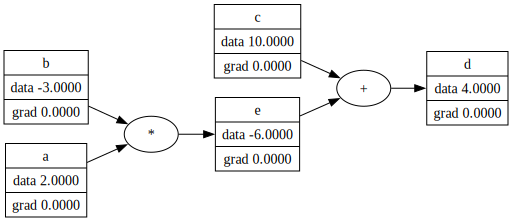

In [ ]:
def simple_data():
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b + c

    d
    d._prev
    d._op

    e = a * b
    e.label = "e"

    d = e + c
    d.label = "d"
    return d


draw_dot(simple_data())

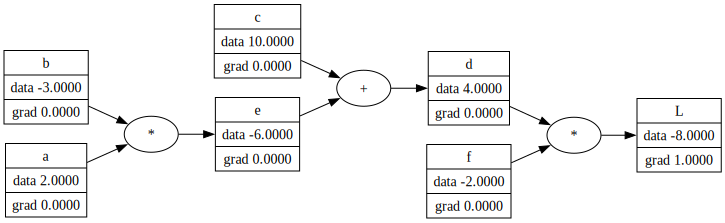

In [ ]:
# introducing a computation process : L = ((a*b) + c)*f
def sample_data() -> Value:
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"

    f = Value(-2.0, label="f")
    L = d * f
    L.label = "L"
    L.grad = 1.0
    return L


draw_dot(sample_data())

In [ ]:
# mul case: the L = d * f, dL/dd = f, d


# to prove, make the baseline value L1 & delta value applied on the specific that leads to L2
# based on (f(x+h)-f(x))/h
def get_grad(i):
    delta = 0.001
    sample = sample_data()
    L1 = sample.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    if i == "b":
        b.data += delta
    elif i == "a":
        a.data += delta
    c = Value(10.0, label="c")
    if i == "c":
        c.data += delta
    e = a * b
    e.label = "e"
    if i == "e":
        e.data += delta
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    if i == "d":
        d.data += delta
    elif i == "f":
        f.data += delta

    L = d * f
    L.label = "L"
    L2 = L.data

    print((L2 - L1) / delta)


# compute the gradient of 'd' ,which is '-2', the value of 'f'
get_grad("d")
# compute the gradient of 'f' which is 4, the value of 'd'
get_grad("f")

-2.000000000000668
3.9999999999995595


In [ ]:
# dd/dc = dd/de  = 1.0  ?  as the add case:  d = e + c  => dd/dc = 1.0 (we call local gradient)
# as L = f * (e + c) => dL/dc = dL/dd * dd/dc  => f * 1.0 = f
# c.grad = -2.0
# e.grad = -2.0
get_grad("c")
get_grad("e")

-1.9999999999988916
-2.000000000000668


In [ ]:
# dL/de = -2.0
# dL / da = (dL / de) * (de / da)
# as e = a * b => de/da = b, de/db = a
# a.grad = dL /da  = -2.0 *b = 6.0
# b.grad = dL / db = -2.0 * a = -4.0
get_grad("a")
get_grad("b")

6.000000000000227
-3.9999999999995595


In [ ]:
# 梯度优化, 步进(学习率)为 0.01
def mini_optimization():
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    a.grad = 6.0
    b.grad = -4.0
    a.data += a.grad * 0.01
    b.data += b.grad * 0.01
    c.data += c.grad * 0.01
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    f.grad = 4.0
    f.data += f.grad * 0.01
    L = d * f
    print(L)


# grows up
mini_optimization()

Value(data=-7.325695999999999, label=)


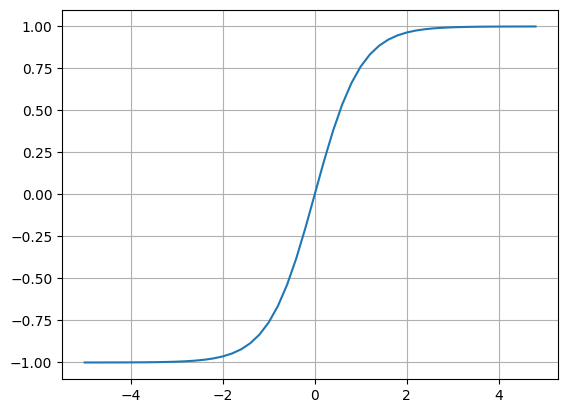

In [ ]:
# 激活函数响应曲线, activition function
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

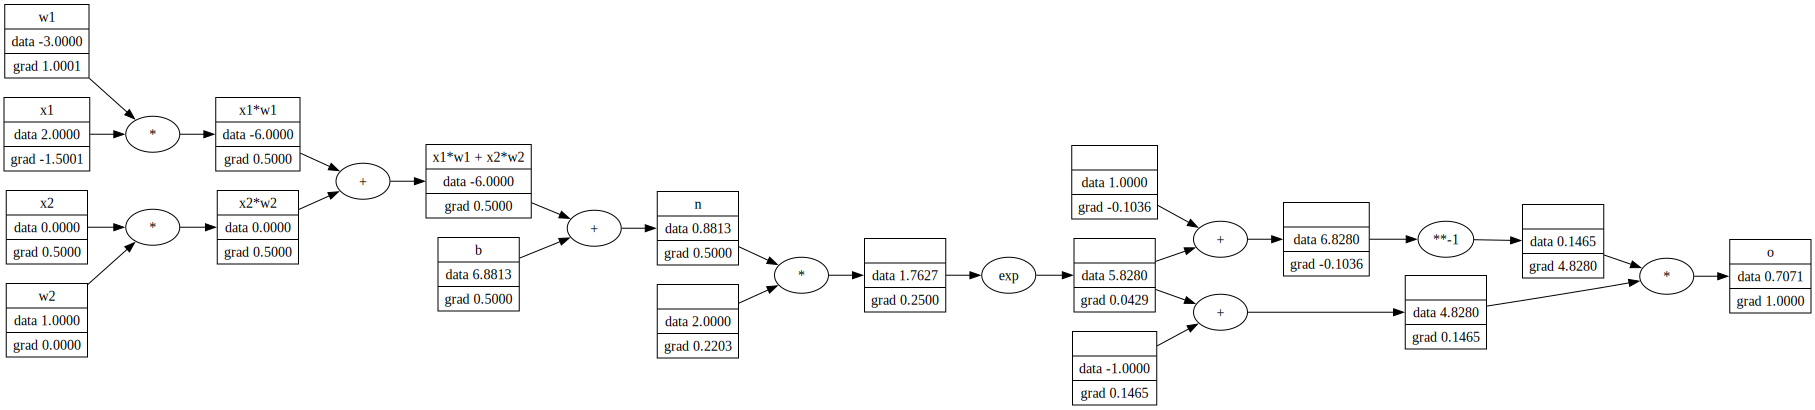

In [102]:
# 单个神经节点 w_i * x_i + b ,w (weight), b(bias)
def single_neuron():
    # inputs
    x_1 = Value(2.0, label="x1")
    x_2 = Value(0.0, label="x2")
    # weights
    w_1 = Value(-3.0, label="w1")
    w_2 = Value(1.0, label="w2")
    # bias
    b = Value(6.881337, label="b")

    x_1w_1 = x_1 * w_1
    x_1w_1.label = "x1*w1"
    x_2w_2 = x_2 * w_2
    x_2w_2.label = "x2*w2"
    x1w1x2w2 = x_1w_1 + x_2w_2
    x1w1x2w2.label = "x1*w1 + x2*w2"
    # output
    n = x1w1x2w2 + b
    n.label = "n"
    # ===> implement the `tanh` inside `Value` and continue
    # o = n.tanh()
    o = n.tanh_without_lib()
    o.label = "o"
    # o.grad = 1.0
    o.backward()
    return o


draw_dot(single_neuron())

0.5000258712642631
[Value(data=-6.0, label=x1*w1), Value(data=0.0, label=x2*w2)]
[Value(data=-6.0, label=x1*w1 + x2*w2), Value(data=6.881337, label=b)]


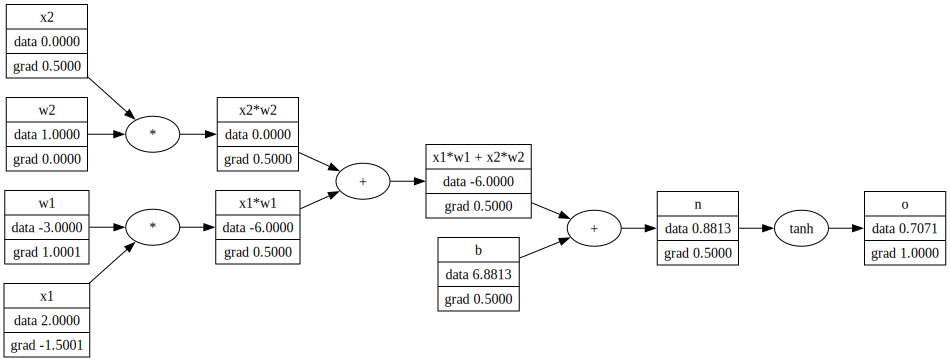

In [ ]:
def manually_back_propagation():
    o = single_neuron()
    # o = tanh(n)
    # do/dn = 1 - tanh(x) ^2  => 1-o^2
    n_grad = 1 - o.data**2
    prv = list(o._prev)
    # n
    prv[0].grad = n_grad
    print(n_grad)
    # b & x1w1x2w2
    prevFromN = list(prv[0]._prev)
    # Case add: the grad is equal to its parent's
    for v in prevFromN:
        v.grad = n_grad

        if len(v._prev) > 0:
            # x1w1 & x2w2
            vChildren = list(v._prev)
            print(vChildren)
            for vv in vChildren:
                vv.grad = v.grad
                deeperChildren = list(vv._prev)
                # x1 w1 x2 w2
                for i in range(len(deeperChildren)):
                    k = 1 if i == 0 else 0
                    node = deeperChildren[i]
                    other = deeperChildren[k]
                    node.grad = other.data * vv.grad

    print(prevFromN)

    return o


draw_dot(manually_back_propagation())

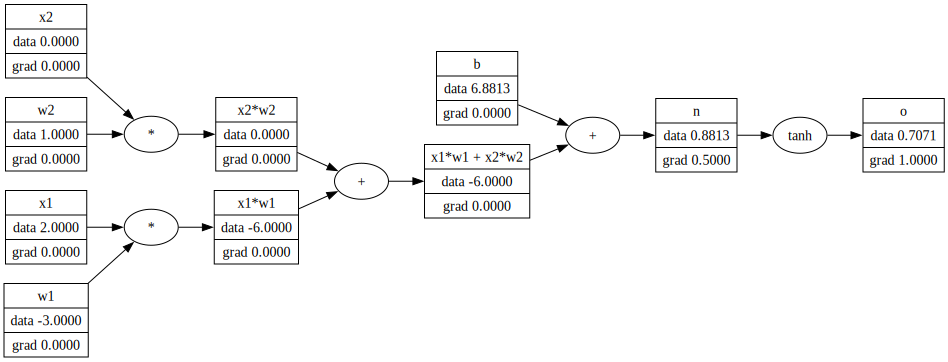

In [ ]:
# ===> implement the back propagation method & property inside Value class
# current the backward only propagates one level
def auto_grad_backward_single_level():
    o = single_neuron()
    o.grad = 1.0
    o._backward()
    return o


draw_dot(auto_grad_backward_single_level())

In [ ]:
# define the method that iterate the nodes
from typing import List


def make_build_topo():
    topo: List[Value] = []
    visited = set["Value"]()

    def build_topo(v: Value):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)  # 深度优先
            topo.append(v)

    return (build_topo, topo, visited)


def test():
    o = single_neuron()
    (build_topo, topo, _) = make_build_topo()
    build_topo(o)
    return topo


test()

[Value(data=-3.0, label=w1),
 Value(data=2.0, label=x1),
 Value(data=-6.0, label=x1*w1),
 Value(data=1.0, label=w2),
 Value(data=0.0, label=x2),
 Value(data=0.0, label=x2*w2),
 Value(data=-6.0, label=x1*w1 + x2*w2),
 Value(data=6.881337, label=b),
 Value(data=0.8813370000000003, label=n),
 Value(data=0.7070884872035019, label=o)]

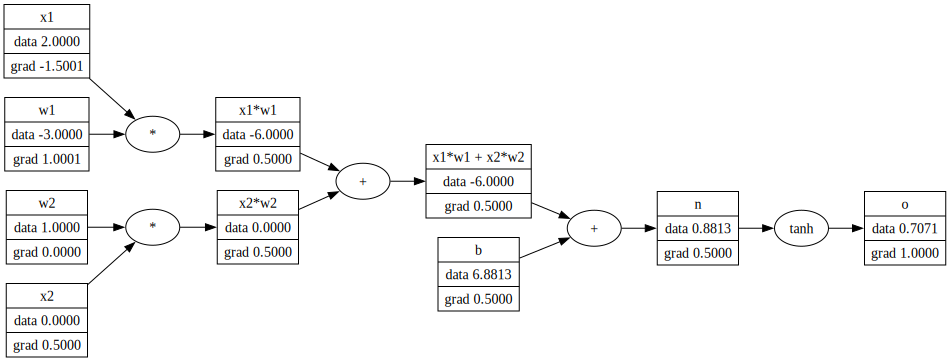

In [ ]:
# ===> implement the back propagation method executing recursively
def auto_grad_backward():
    o = single_neuron()
    o.grad = 1.0
    (build_topo, topo, _) = make_build_topo()
    build_topo(o)
    for node in reversed(topo):
        node._backward()
    return o


draw_dot(auto_grad_backward())

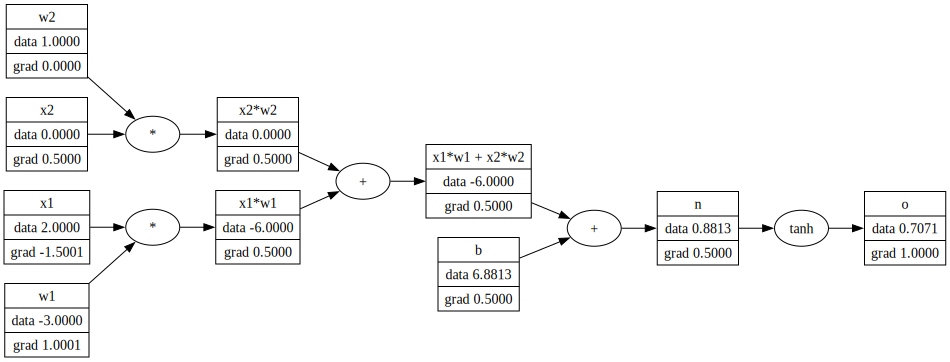

In [ ]:
# ===> move the `auto_grad_backward` inside the `Value` class
def auto_grad_backward_as_method():
    o = single_neuron()
    o.backward()
    return o


draw_dot(auto_grad_backward_as_method())

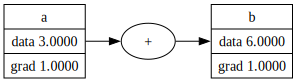

In [ ]:
# potential bug
def potential_bug():
    a = Value(3.0, label="a")
    b = a + a
    b.label = "b"
    b.backward()
    return b


# the a's gradient is 1.0 , which is supposed to be 2.0
# b = 2a db/da = 2.0
draw_dot(potential_bug())

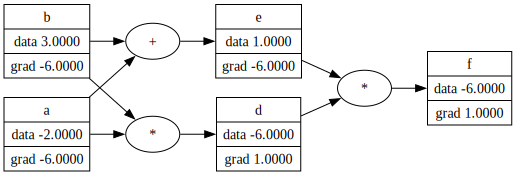

In [ ]:
def more_complicated_version_bug():
    a = Value(-2.0, label="a")
    b = Value(3.0, label="b")
    d = a * b
    d.label = "d"
    e = a + b
    e.label = "e"
    f = d * e
    f.label = "f"

    f.backward()
    return f


# reason conculsion: value node contributes more than once in a single calculation process
# but the gradient is evaluated and overriden
# instead of overriding the gradient, we should accumulate each computation result. Refactoring setting the gradient.
draw_dot(more_complicated_version_bug())

In [91]:
# impl the __add__ method to support Value object add with primitive numbers
def supports_primitive_number():
    a = Value(2.0)
    print(a * 2)
    print(2 * a)


supports_primitive_number()

Value(data=4.0, label=)
Value(data=4.0, label=)
